In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("S1_20172024_NTB_GLOID_UniqueLakesv1.csv")

In [3]:
df.shape

(2967, 18)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2967 entries, 0 to 2966
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   geometry               2967 non-null   str    
 1   GLO_ID                 2967 non-null   str    
 2   COUNTRY                2967 non-null   str    
 3   BASIN                  2967 non-null   str    
 4   CONNECTIVITY           2967 non-null   str    
 5   DATA_SOURCE            2967 non-null   str    
 6   EXPANSION_RATE         2967 non-null   float64
 7   EXPANSION_UNCERTAINTY  2967 non-null   float64
 8   EXPANSION_RATE_SIG     2167 non-null   object 
 9   S2_MSTAT               2967 non-null   float64
 10  LONGITUDE              2967 non-null   float64
 11  LATITUDE               2967 non-null   float64
 12  GTNG_REGION_O2         2967 non-null   str    
 13  ELEVATION_MIN          2967 non-null   float64
 14  ELEVATION_MEDIAN       2967 non-null   float64
 15  ELEVATION_MEAN 

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing

EXPANSION_RATE_SIG       800
geometry                   0
LONGITUDE                  0
AREA_DISSOLVED             0
ELEVATION_MEAN             0
ELEVATION_MEDIAN           0
ELEVATION_MIN              0
GTNG_REGION_O2             0
LATITUDE                   0
S2_MSTAT                   0
GLO_ID                     0
EXPANSION_UNCERTAINTY      0
EXPANSION_RATE             0
DATA_SOURCE                0
CONNECTIVITY               0
BASIN                      0
COUNTRY                    0
PERIMETER_DISSOLVED        0
dtype: int64

In [6]:
df['GLO_ID'].duplicated().sum()

np.int64(0)

In [7]:
df.tail(10)

,geometry,GLO_ID,COUNTRY,BASIN,CONNECTIVITY,DATA_SOURCE,EXPANSION_RATE,EXPANSION_UNCERTAINTY,EXPANSION_RATE_SIG,S2_MSTAT,LONGITUDE,LATITUDE,GTNG_REGION_O2,ELEVATION_MIN,ELEVATION_MEDIAN,ELEVATION_MEAN,AREA_DISSOLVED,PERIMETER_DISSOLVED
2957,"{""type"":""MultiPolygon"",""coordinates"":[[[[-5814...",GLO_88.6431_28.72565,China,Koshi,Non Glacier-fed,Sentinel-1,0.0002,0.0017,False,0.0,88.64310,28.72565,15-02,4846.0,4848.039814,4847.812012,0.013466,0.561919
2958,"{""type"":""MultiPolygon"",""coordinates"":[[[[-5815...",GLO_88.65343_28.58875,China,Koshi,Non Glacier-fed,Sentinel-1,0.0000,0.0000,NaN,0.0,88.65343,28.58875,15-02,5012.0,5013.196051,5013.158691,0.005162,0.352620
2959,"{""type"":""MultiPolygon"",""coordinates"":[[[[-5782...",GLO_88.69068_28.56859,China,Koshi,Non Glacier-fed,Sentinel-1,0.0000,0.0004,False,1.0,88.69076,28.56854,15-02,5420.0,5420.898296,5420.708008,0.019972,0.674438
2960,"{""type"":""MultiPolygon"",""coordinates"":[[[[-5780...",GLO_88.69327_28.55744,China,Koshi,Non Glacier-fed,Sentinel-1,0.0000,0.0000,NaN,0.0,88.69327,28.55744,15-02,5475.0,5475.918647,5475.855469,0.004988,0.410081
2961,"{""type"":""MultiPolygon"",""coordinates"":[[[[-5762...",GLO_88.71294_28.56171,China,Koshi,Non Glacier-fed,Sentinel-1,0.0000,0.0005,False,0.0,88.71294,28.56171,15-02,5501.0,5501.540749,5501.150879,0.006791,0.370400
2962,"{""type"":""MultiPolygon"",""coordinates"":[[[[-5765...",GLO_88.71356_28.51363,China,Koshi,Non Glacier-fed,Sentinel-1,0.0000,0.0003,False,1.0,88.71366,28.51383,15-02,5355.0,5356.746355,5356.746094,0.010593,0.487488
2963,"{""type"":""MultiPolygon"",""coordinates"":[[[[-5759...",GLO_88.71616_28.5628,China,Koshi,Non Glacier-fed,Sentinel-1,0.0001,0.0002,False,1.0,88.71609,28.56288,15-02,5539.0,5539.500000,5539.227539,0.002780,0.255635
2964,"{""type"":""MultiPolygon"",""coordinates"":[[[[-5757...",GLO_88.71857_28.55398,China,Koshi,Non Glacier-fed,Sentinel-1,0.0000,0.0009,False,1.0,88.71852,28.55389,15-02,5496.0,5497.164165,5496.895996,0.026861,0.838642
2965,"{""type"":""MultiPolygon"",""coordinates"":[[[[-5616...",GLO_88.88116_28.45517,China,Koshi,Non Glacier-fed,Sentinel-1,-0.0001,0.0005,False,0.0,88.88116,28.45517,15-02,5227.0,5227.532192,5227.257324,0.004730,0.330635
2966,"{""type"":""MultiPolygon"",""coordinates"":[[[[-7910...",GLO_86.43243_27.93829,China,Koshi,Glacier-fed,Sentinel-1,0.0462,0.0100,True,1.0,86.44793,27.94789,15-02,5031.0,5040.053951,5040.411621,0.071006,1.413616


In [8]:
df[['EXPANSION_RATE', 
    'EXPANSION_UNCERTAINTY', 
    'ELEVATION_MEDIAN', 
    'ELEVATION_MEAN',
    'AREA_DISSOLVED', 
    'PERIMETER_DISSOLVED']].describe()

,EXPANSION_RATE,EXPANSION_UNCERTAINTY,ELEVATION_MEDIAN,ELEVATION_MEAN,AREA_DISSOLVED,PERIMETER_DISSOLVED
count,2967.000000,2967.000000,2967.000000,2967.000000,2967.000000,2967.000000
mean,0.000263,0.001561,5028.642777,5028.907365,0.064508,1.035289
std,0.004953,0.006366,455.393749,455.394037,0.222698,1.233383
min,-0.115100,0.000000,1996.500000,1996.816650,0.001032,0.147861
25%,-0.000200,0.000000,4743.404086,4744.036377,0.007912,0.448876
50%,0.000000,0.000500,5091.416153,5091.426270,0.018720,0.695841
75%,0.000200,0.001200,5374.067056,5373.923584,0.046737,1.155369
max,0.101200,0.158200,6035.461100,6035.660645,5.487133,16.912989


In [9]:
for col in ["COUNTRY", "BASIN", "CONNECTIVITY"]:
    print(df[col].value_counts(dropna=False))

COUNTRY
Nepal    1578
China    1353
India      36
Name: count, dtype: int64
BASIN
Koshi      1722
Karnali     878
Gandaki     367
Name: count, dtype: int64
CONNECTIVITY
Glacier-fed        1701
Non Glacier-fed    1266
Name: count, dtype: int64


In [10]:
df.groupby("BASIN").agg(
    lakes=("GLO_ID", "count"),
    mean_area=("AREA_DISSOLVED", "mean"),
    median_area=("AREA_DISSOLVED", "median"),
    mean_expansion=("EXPANSION_RATE", "mean")
)

,lakes,mean_area,median_area,mean_expansion
BASIN,,,,
Gandaki,367,0.056678,0.020583,0.000276
Karnali,878,0.041827,0.017537,-0.000067
Koshi,1722,0.077741,0.018959,0.000429


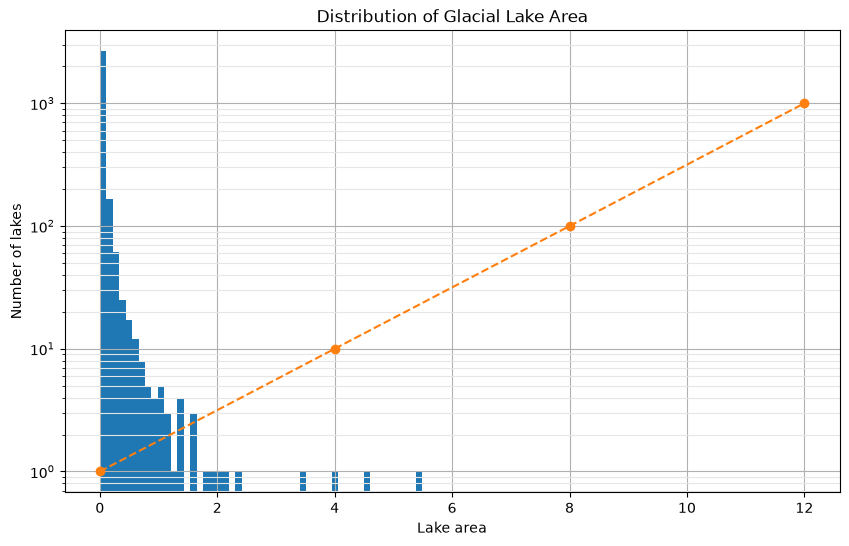

In [15]:
plt.figure(figsize=(10,6))

plt.hist(
    df["AREA_DISSOLVED"],
    bins=50
)
x = np.arange(4)
plt.semilogy(4*x, 10**x, 'o--')
plt.grid()
plt.grid(which="minor", color="0.9")
plt.xlabel("Lake area")
plt.ylabel("Number of lakes")
plt.title("Distribution of Glacial Lake Area")

plt.show()

In [16]:
df["EXPANSION_RATE"].describe(
    percentiles=[.5, .75, .9, .95, .99]
)

count    2967.000000
mean        0.000263
std         0.004953
min        -0.115100
50%         0.000000
75%         0.000200
90%         0.000700
95%         0.001700
99%         0.011334
max         0.101200
Name: EXPANSION_RATE, dtype: float64

In [19]:
df["SIGNIFICANT_EXPANSION"] = (
    df["EXPANSION_RATE_SIG"]
    .fillna(0)
)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2967 entries, 0 to 2966
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   geometry               2967 non-null   str    
 1   GLO_ID                 2967 non-null   str    
 2   COUNTRY                2967 non-null   str    
 3   BASIN                  2967 non-null   str    
 4   CONNECTIVITY           2967 non-null   str    
 5   DATA_SOURCE            2967 non-null   str    
 6   EXPANSION_RATE         2967 non-null   float64
 7   EXPANSION_UNCERTAINTY  2967 non-null   float64
 8   EXPANSION_RATE_SIG     2167 non-null   object 
 9   S2_MSTAT               2967 non-null   float64
 10  LONGITUDE              2967 non-null   float64
 11  LATITUDE               2967 non-null   float64
 12  GTNG_REGION_O2         2967 non-null   str    
 13  ELEVATION_MIN          2967 non-null   float64
 14  ELEVATION_MEDIAN       2967 non-null   float64
 15  ELEVATION_MEAN 

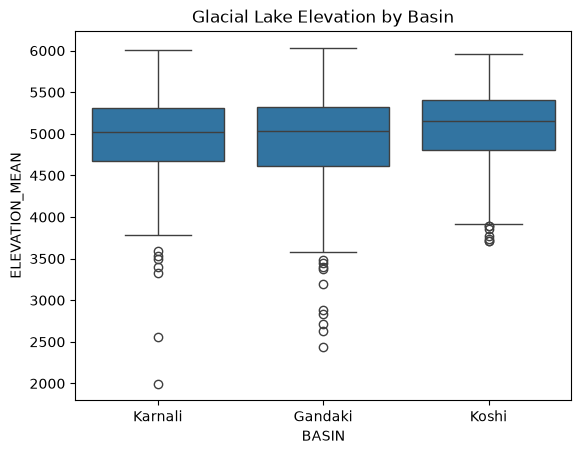

In [21]:
sns.boxplot(
    data=df,
    x="BASIN",
    y="ELEVATION_MEAN"
)

plt.title("Glacial Lake Elevation by Basin")
plt.show()

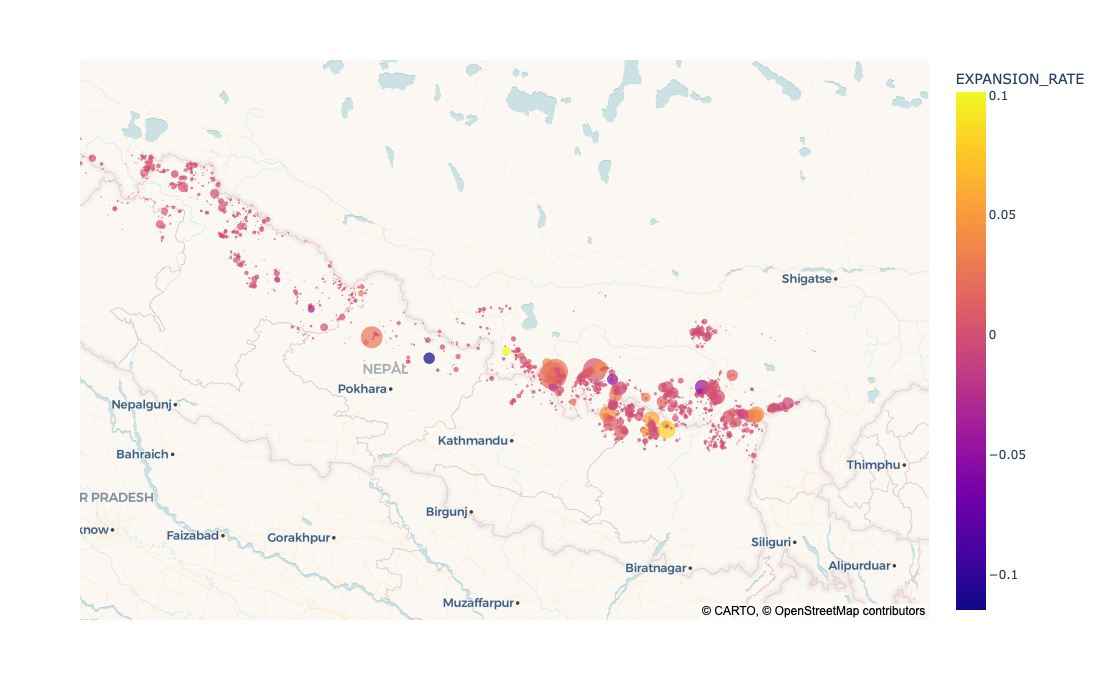

In [31]:
#Koshi is a bit higher overall but most GLs range around 5000-5500m
import plotly.express as px

fig = px.scatter_map(
    df,
    lat="LATITUDE",
    lon="LONGITUDE",
    color="EXPANSION_RATE",
    size="AREA_DISSOLVED",
    hover_name="GLO_ID",
    zoom=6,
    height=700
)
fig.show()